# MS 22: Theory Assignment 1
## Multi-Output Time-Series Forecasting using LSTM/GRU

**Department of Computer Science, Faculty of Sciences**  
**Jamia Millia Islamia**

---

| Detail | Info |
|--------|------|
| **Roll No** | 26 |
| **Dataset** | IOC.csv (Indian Oil Corporation) |
| **Source** | NIFTY-50 Stock Market Data (2000–2021), Kaggle |
| **Task** | Multi-Output Time-Series Forecasting |
| **Framework** | PyTorch (LSTM & GRU) |

---

## 1. Import Libraries

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"Pandas version:  {pd.__version__}")

Using device: cpu
PyTorch version: 2.11.0+cu130
Pandas version:  3.0.2


## 2. Load Dataset

> Download `IOC.csv` from [Kaggle NIFTY-50 dataset](https://www.kaggle.com/datasets/rohanrao/nifty50-stock-market-data/data) and place it in the same directory as this notebook.

In [17]:
# ── Load raw data ──────────────────────────────────────────────────────────────
df_raw = pd.read_csv('IOC.csv')
print(f"Raw shape : {df_raw.shape}")
print("\nFirst 5 rows:")
df_raw.head()

Raw shape : (5306, 15)

First 5 rows:


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,IOC,EQ,254.00,260.0,273.25,250.00,267.35,270.85,258.55,23700,6.127648e+11,NaN,NaN,NaN
1,2000-01-04,IOC,EQ,270.85,260.0,268.00,254.10,267.00,264.40,259.80,24400,6.339112e+11,NaN,NaN,NaN
2,2000-01-05,IOC,EQ,264.40,264.9,265.00,257.00,261.35,261.30,260.66,18900,4.926382e+11,NaN,NaN,NaN
3,2000-01-06,IOC,EQ,261.30,258.0,263.00,256.05,263.00,260.10,259.81,18150,4.715515e+11,NaN,NaN,NaN
4,2000-01-07,IOC,EQ,260.10,259.9,267.00,253.25,267.00,264.45,260.11,17650,4.590902e+11,NaN,NaN,NaN


## 3. Data Cleaning & Pre-processing

Steps performed:
1. Parse `Date` column and set as index  
2. Retain the **11 required features**  
3. Handle missing / NaN values  
4. Remove duplicate rows  
5. Fix incorrect data types  

In [18]:
# ── 3.1  Parse dates ───────────────────────────────────────────────────────────
df = df_raw.copy()
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df = df.sort_values('Date').reset_index(drop=True)

# ── 3.2  Select the 11 required features ──────────────────────────────────────
FEATURE_COLS = [
    'Prev Close', 'Open', 'High', 'Low', 'Last',
    'Close', 'VWAP', 'Volume', 'Turnover',
    'Trades', 'Deliverable Volume'
]

# Map alternate column names if present in CSV
col_rename = {
    '%Deliverable'  : 'Deliverable Volume',
    'Deliverble'    : 'Deliverable Volume',
    '%Deliverble'   : 'Deliverable Volume',
}
df.rename(columns=col_rename, inplace=True)

# Keep only Date + feature cols that exist
available = [c for c in FEATURE_COLS if c in df.columns]
print(f"Available features ({len(available)}): {available}")

df = df[['Date'] + available].copy()
print(f"\nDataframe shape after column selection: {df.shape}")

Available features (11): ['Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume']

Dataframe shape after column selection: (5306, 13)


In [19]:
# ── 3.3  Fix incorrect dtypes ──────────────────────────────────────────────────
# Reset to clean single-column access (handles duplicate col names in raw CSV)
df = df.loc[:, ~df.columns.duplicated()].copy()

for col in available:
    series = df[col]
    # Ensure it's a plain 1-D Series (not a DataFrame slice)
    if isinstance(series, pd.DataFrame):
        series = series.iloc[:, 0]

    cleaned = series.astype(str).str.replace(',', '').str.strip()
    df[col] = pd.to_numeric(cleaned, errors='coerce')

print("Data types after conversion:")
print(df.dtypes)

Data types after conversion:
Date                  datetime64[us]
Prev Close                   float64
Open                         float64
High                         float64
Low                          float64
Last                         float64
Close                        float64
VWAP                         float64
Volume                         int64
Turnover                     float64
Trades                       float64
Deliverable Volume           float64
dtype: object


In [20]:
# ── 3.4  Check missing values ──────────────────────────────────────────────────
print("\nMissing values per column (before handling):")
print(df[available].isnull().sum())

# Forward-fill then backward-fill (preserves time-series continuity)
df[available] = df[available].ffill().bfill()

print("\nMissing values per column (after handling):")
print(df[available].isnull().sum())


Missing values per column (before handling):
Prev Close               0
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                2850
Deliverable Volume     509
dtype: int64

Missing values per column (after handling):
Prev Close            0
Open                  0
High                  0
Low                   0
Last                  0
Close                 0
VWAP                  0
Volume                0
Turnover              0
Trades                0
Deliverable Volume    0
dtype: int64


In [21]:
# ── 3.5  Remove duplicates ─────────────────────────────────────────────────────
before = len(df)
df.drop_duplicates(subset=['Date'], keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Duplicates removed: {before - len(df)}  |  Final rows: {len(df)}")

print(f"\nDate range : {df['Date'].min().date()}  →  {df['Date'].max().date()}")
df.describe()

Duplicates removed: 3212  |  Final rows: 2094

Date range : 2000-01-02  →  2021-12-04


,Date,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume
count,2093,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2094.000000,2.094000e+03,2.094000e+03,2094.000000,2.094000e+03
mean,2010-08-13 22:14:02.809364,320.755253,321.506351,327.001600,315.651242,320.875812,320.873973,321.423190,2.940178e+06,5.517863e+13,24803.479943,1.144297e+06
min,2000-01-02 00:00:00,73.900000,73.950000,75.000000,72.800000,73.950000,74.100000,74.210000,3.500000e+02,9.063250e+09,308.000000,2.697000e+03
25%,2005-04-01 00:00:00,200.150000,201.000000,203.125000,198.250000,200.012500,200.175000,200.695000,1.963512e+05,6.926319e+12,12758.000000,8.746650e+04
50%,2010-08-07 00:00:00,335.500000,335.925000,341.175000,329.775000,335.000000,335.275000,336.405000,5.673295e+05,2.125416e+13,12758.000000,2.439715e+05
75%,2015-12-06 00:00:00,420.637500,420.312500,427.875000,413.387500,419.600000,419.737500,420.337500,1.830884e+06,6.963164e+13,26063.000000,8.525930e+05
max,2021-12-04 00:00:00,794.950000,800.000000,803.900000,775.550000,781.000000,785.100000,789.830000,8.088540e+07,9.536325e+14,379888.000000,3.139694e+07
std,NaN,139.466148,139.852895,142.695231,136.998053,139.574401,139.615775,139.951624,6.604474e+06,8.374950e+13,27297.521562,2.373270e+06


## 4. Train / Test Split & Normalization

In [22]:
# ── 4.1  80/20 chronological split ────────────────────────────────────────────
split_idx = int(len(df) * 0.80)

train_df = df.iloc[:split_idx].reset_index(drop=True)
test_df  = df.iloc[split_idx:].reset_index(drop=True)

print(f"Train : {len(train_df)} rows  ({train_df['Date'].min().date()} → {train_df['Date'].max().date()})")
print(f"Test  : {len(test_df)}  rows  ({test_df['Date'].min().date()} → {test_df['Date'].max().date()})")

# ── 4.2  MinMax normalization (fit ONLY on train set) ─────────────────────────
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_df[available].values)
test_scaled  = scaler.transform(test_df[available].values)

print(f"\nFeature columns used ({len(available)}): {available}")
print(f"train_scaled shape: {train_scaled.shape}")
print(f"test_scaled  shape: {test_scaled.shape}")

Train : 1675 rows  (2000-01-02 → 2017-01-09)
Test  : 419  rows  (2017-01-11 → 2021-12-04)

Feature columns used (11): ['Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume']
train_scaled shape: (1675, 11)
test_scaled  shape: (419, 11)


## 5. Sliding-Window Dataset

Two configurations (as per assignment):

| Config | Input window | Output window | Overlap |
|--------|-------------|---------------|----------|
| Example 1 | 5 days | 5 days | 5 days |
| Example 2 | 10 days | 5 days | 5 days |

In [23]:
class TimeSeriesDataset(Dataset):
    """
    Sliding-window dataset for multi-output time-series forecasting.
    
    Args:
        data      : numpy array of shape (T, n_features)
        input_len : number of past time steps used as input
        pred_len  : number of future time steps to predict
        step      : stride between consecutive windows (overlap = input_len - step)
    """
    def __init__(self, data, input_len: int, pred_len: int, step: int = 1):
        self.X, self.y = [], []
        total = len(data)
        for start in range(0, total - input_len - pred_len + 1, step):
            x_window = data[start : start + input_len]
            y_window = data[start + input_len : start + input_len + pred_len]
            self.X.append(x_window)
            self.y.append(y_window)
        self.X = torch.tensor(np.array(self.X), dtype=torch.float32)
        self.y = torch.tensor(np.array(self.y), dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# ── Hyperparameters ────────────────────────────────────────────────────────────
INPUT_LEN  = 10   # last 10 days as input  (Example 2 from assignment)
PRED_LEN   = 5    # predict next 5 days
STEP       = 5    # stride → overlap = INPUT_LEN − STEP = 5 days
BATCH_SIZE = 32

train_dataset = TimeSeriesDataset(train_scaled, INPUT_LEN, PRED_LEN, STEP)
test_dataset  = TimeSeriesDataset(test_scaled,  INPUT_LEN, PRED_LEN, STEP)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Window config  : input={INPUT_LEN} days  →  predict={PRED_LEN} days  (step={STEP})")
print(f"Train samples  : {len(train_dataset)}")
print(f"Test  samples  : {len(test_dataset)}")

xb, yb = next(iter(train_loader))
print(f"\nBatch X shape  : {xb.shape}   (batch, input_len, n_features)")
print(f"Batch y shape  : {yb.shape}   (batch, pred_len,  n_features)")

Window config  : input=10 days  →  predict=5 days  (step=5)
Train samples  : 333
Test  samples  : 81

Batch X shape  : torch.Size([32, 10, 11])   (batch, input_len, n_features)
Batch y shape  : torch.Size([32, 5, 11])   (batch, pred_len,  n_features)


## 6. Model Definitions

Both **LSTM** and **GRU** follow the same architecture:

```
Input (input_len × n_features)
    └─► LSTM / GRU  (2 layers, hidden=128, dropout=0.2)
          └─► Last hidden state  →  FC  →  (pred_len × n_features)
```

In [24]:
class LSTMForecaster(nn.Module):
    def __init__(self, n_features: int, hidden: int, num_layers: int,
                 pred_len: int, dropout: float = 0.2):
        super().__init__()
        self.pred_len   = pred_len
        self.n_features = n_features
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden, pred_len * n_features)

    def forward(self, x):
        # x: (B, seq_len, n_features)
        out, _ = self.lstm(x)          # out: (B, seq_len, hidden)
        last   = out[:, -1, :]         # last step: (B, hidden)
        out    = self.fc(last)          # (B, pred_len * n_features)
        return out.view(-1, self.pred_len, self.n_features)


class GRUForecaster(nn.Module):
    def __init__(self, n_features: int, hidden: int, num_layers: int,
                 pred_len: int, dropout: float = 0.2):
        super().__init__()
        self.pred_len   = pred_len
        self.n_features = n_features
        self.gru = nn.GRU(
            input_size=n_features,
            hidden_size=hidden,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden, pred_len * n_features)

    def forward(self, x):
        out, _ = self.gru(x)
        last   = out[:, -1, :]
        out    = self.fc(last)
        return out.view(-1, self.pred_len, self.n_features)


# ── Instantiate models ────────────────────────────────────────────────────────
N_FEATURES  = len(available)
HIDDEN      = 128
NUM_LAYERS  = 2
DROPOUT     = 0.2

lstm_model = LSTMForecaster(N_FEATURES, HIDDEN, NUM_LAYERS, PRED_LEN, DROPOUT).to(device)
gru_model  = GRUForecaster (N_FEATURES, HIDDEN, NUM_LAYERS, PRED_LEN, DROPOUT).to(device)

print("── LSTM Model ──")
print(lstm_model)
lstm_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
gru_params  = sum(p.numel() for p in gru_model.parameters()  if p.requires_grad)
print(f"\nLSTM trainable params : {lstm_params:,}")
print(f"GRU  trainable params : {gru_params:,}")

── LSTM Model ──
LSTMForecaster(
  (lstm): LSTM(11, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=55, bias=True)
)

LSTM trainable params : 211,383
GRU  trainable params : 160,311


## 7. Training Loop

In [25]:
def train_model(model, train_loader, test_loader, epochs: int = 80,
                lr: float = 1e-3, patience: int = 15):
    """
    Train model with Adam optimiser, MSE loss, and early stopping.
    Returns training & validation loss history.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, patience=7, factor=0.5)
    criterion = nn.MSELoss()

    train_losses, val_losses = [], []
    best_val, no_improve = float('inf'), 0
    best_state = None

    for epoch in range(1, epochs + 1):
        # ─── Train ───────────────────────────────────────────────────────────
        model.train()
        batch_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            batch_losses.append(loss.item())
        train_loss = np.mean(batch_losses)

        # ─── Validate ────────────────────────────────────────────────────────
        model.eval()
        vbatch = []
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred   = model(xb)
                vbatch.append(criterion(pred, yb).item())
        val_loss = np.mean(vbatch)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        if val_loss < best_val:
            best_val   = val_loss
            no_improve = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}/{epochs}  "
                  f"train_loss={train_loss:.6f}  val_loss={val_loss:.6f}")

        if no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch}  (best val_loss={best_val:.6f})")
            break

    model.load_state_dict(best_state)
    return train_losses, val_losses

In [26]:
EPOCHS = 100

print("═" * 60)
print("  Training LSTM")
print("═" * 60)
lstm_train_losses, lstm_val_losses = train_model(
    lstm_model, train_loader, test_loader, epochs=EPOCHS)

print("\n" + "═" * 60)
print("  Training GRU")
print("═" * 60)
gru_train_losses, gru_val_losses = train_model(
    gru_model, train_loader, test_loader, epochs=EPOCHS)

════════════════════════════════════════════════════════════
  Training LSTM
════════════════════════════════════════════════════════════
Epoch   1/100  train_loss=0.080536  val_loss=0.329220
Epoch  10/100  train_loss=0.008355  val_loss=0.337182

Early stopping at epoch 16  (best val_loss=0.329220)

════════════════════════════════════════════════════════════
  Training GRU
════════════════════════════════════════════════════════════
Epoch   1/100  train_loss=0.065912  val_loss=0.358442
Epoch  10/100  train_loss=0.008189  val_loss=0.293706
Epoch  20/100  train_loss=0.007510  val_loss=0.193582
Epoch  30/100  train_loss=0.006447  val_loss=0.203915

Early stopping at epoch 35  (best val_loss=0.193582)


## 8. Evaluate: MSE, RMSE, MAE

In [27]:
def get_predictions(model, loader):
    """Return (preds_scaled, true_scaled) as numpy arrays."""
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            pred = model(xb.to(device)).cpu().numpy()
            preds.append(pred)
            trues.append(yb.numpy())
    preds = np.concatenate(preds, axis=0)   # (N, pred_len, n_features)
    trues = np.concatenate(trues, axis=0)
    return preds, trues


def inverse_transform(arr, scaler, n_features):
    """Reshape (N, pred_len, n_features) → inverse scale → reshape back."""
    N, L, F = arr.shape
    arr_2d  = arr.reshape(-1, F)
    inv     = scaler.inverse_transform(arr_2d)
    return inv.reshape(N, L, F)


def compute_metrics(true_inv, pred_inv, feature_names):
    """Compute per-feature and overall MSE / RMSE / MAE."""
    rows = []
    for i, fname in enumerate(feature_names):
        t = true_inv[:, :, i].ravel()
        p = pred_inv[:, :, i].ravel()
        mse  = mean_squared_error(t, p)
        rmse = np.sqrt(mse)
        mae  = mean_absolute_error(t, p)
        rows.append({'Feature': fname, 'MSE': mse, 'RMSE': rmse, 'MAE': mae})
    metrics_df = pd.DataFrame(rows).set_index('Feature')
    # Overall (all features flattened)
    t_all = true_inv.ravel()
    p_all = pred_inv.ravel()
    mse_all  = mean_squared_error(t_all, p_all)
    metrics_df.loc['** OVERALL **'] = {
        'MSE' : mse_all,
        'RMSE': np.sqrt(mse_all),
        'MAE' : mean_absolute_error(t_all, p_all)
    }
    return metrics_df


# ── Predictions ───────────────────────────────────────────────────────────────
lstm_preds, lstm_trues = get_predictions(lstm_model, test_loader)
gru_preds,  gru_trues  = get_predictions(gru_model,  test_loader)

# Inverse-transform to original scale
lstm_preds_inv = inverse_transform(lstm_preds, scaler, N_FEATURES)
lstm_trues_inv = inverse_transform(lstm_trues, scaler, N_FEATURES)
gru_preds_inv  = inverse_transform(gru_preds,  scaler, N_FEATURES)
gru_trues_inv  = inverse_transform(gru_trues,  scaler, N_FEATURES)

print("══════════════════════════════════════════")
print("  LSTM — Test Set Metrics (original scale)")
print("══════════════════════════════════════════")
lstm_metrics = compute_metrics(lstm_trues_inv, lstm_preds_inv, available)
print(lstm_metrics.to_string())

print("\n══════════════════════════════════════════")
print("  GRU — Test Set Metrics (original scale)")
print("══════════════════════════════════════════")
gru_metrics = compute_metrics(gru_trues_inv, gru_preds_inv, available)
print(gru_metrics.to_string())

══════════════════════════════════════════
  LSTM — Test Set Metrics (original scale)
══════════════════════════════════════════
                             MSE          RMSE           MAE
Feature                                                     
Prev Close          2.000000e+04  1.414213e+02  1.303661e+02
Open                2.719283e+04  1.649025e+02  1.436397e+02
High                4.005371e+04  2.001342e+02  1.741224e+02
Low                 2.234957e+04  1.494977e+02  1.406962e+02
Last                1.735761e+04  1.317483e+02  1.263776e+02
Close               2.991456e+04  1.729583e+02  1.536909e+02
VWAP                3.209101e+04  1.791396e+02  1.573385e+02
Volume              2.258649e+14  1.502880e+07  1.074078e+07
Turnover            2.323529e+28  1.524312e+14  1.076895e+14
Trades              3.599887e+09  5.999906e+04  4.732425e+04
Deliverable Volume  2.829006e+13  5.318840e+06  3.885205e+06
** OVERALL **       2.112299e+27  4.595975e+13  9.789951e+12

════════════════

## 9. Plots

### 9.1 Training & Validation Loss Curves

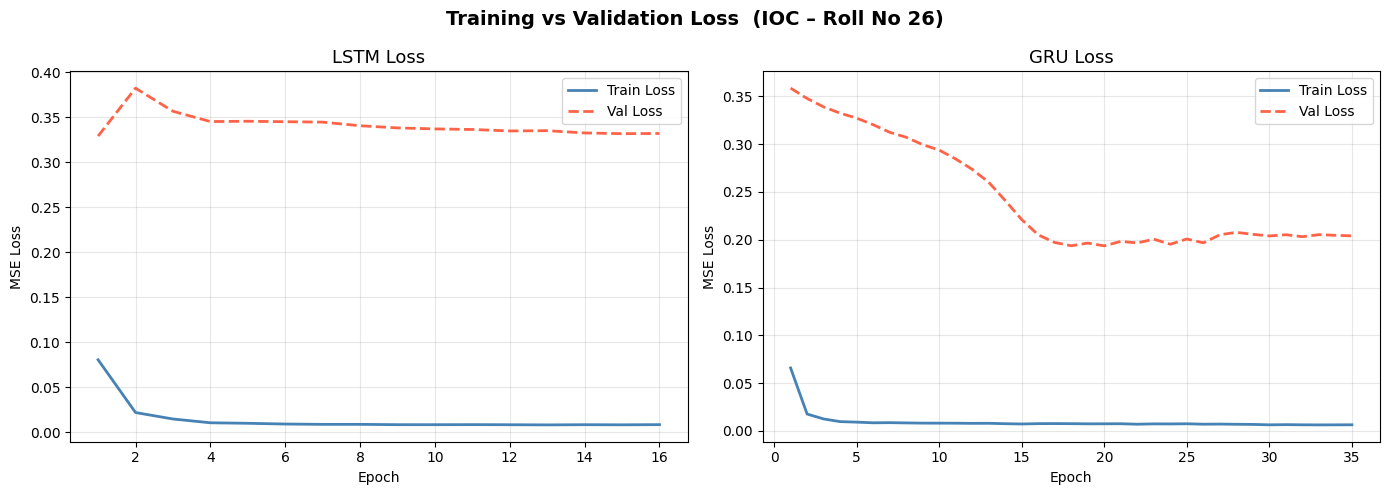

Saved: loss_curves.png


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training vs Validation Loss  (IOC – Roll No 26)', fontsize=14, fontweight='bold')

for ax, (name, tl, vl) in zip(axes, [
    ('LSTM', lstm_train_losses, lstm_val_losses),
    ('GRU',  gru_train_losses,  gru_val_losses)
]):
    epochs_range = range(1, len(tl) + 1)
    ax.plot(epochs_range, tl, label='Train Loss', color='steelblue',  lw=2)
    ax.plot(epochs_range, vl, label='Val Loss',   color='tomato',     lw=2, linestyle='--')
    ax.set_title(f'{name} Loss', fontsize=13)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: loss_curves.png")

### 9.2 Performance Metrics Bar Chart (RMSE per feature)

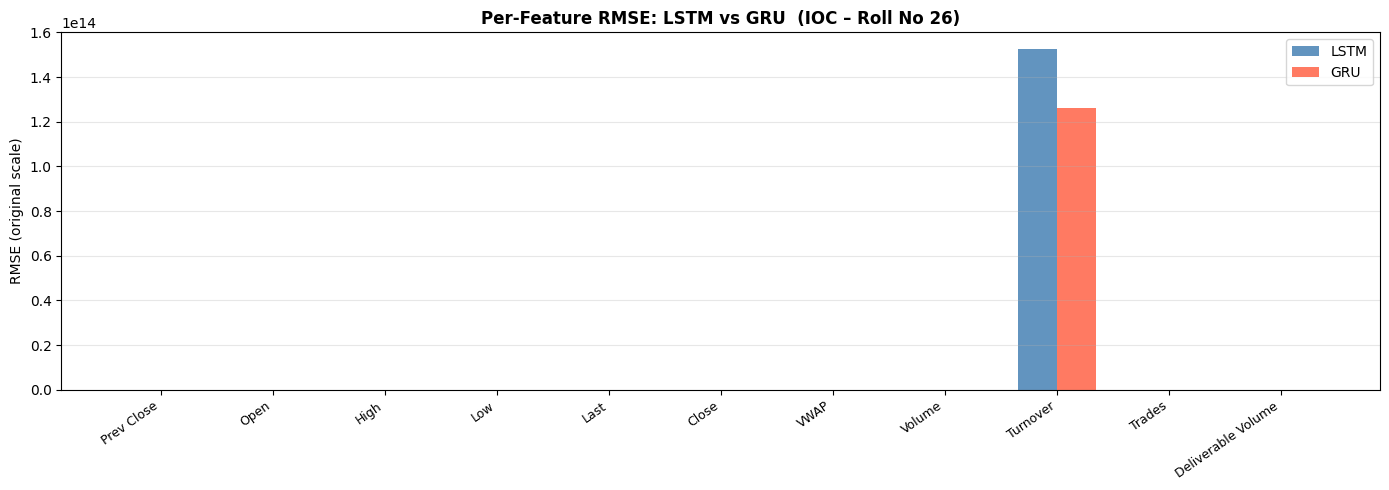

Saved: rmse_bar.png


In [29]:
feat_only = [f for f in available]  # exclude OVERALL row for bar chart
lstm_rmse = lstm_metrics.loc[feat_only, 'RMSE'].values
gru_rmse  = gru_metrics.loc[feat_only,  'RMSE'].values

x = np.arange(len(feat_only))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
bars1 = ax.bar(x - width/2, lstm_rmse, width, label='LSTM', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, gru_rmse,  width, label='GRU',  color='tomato',    alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(feat_only, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('RMSE (original scale)')
ax.set_title('Per-Feature RMSE: LSTM vs GRU  (IOC – Roll No 26)', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('rmse_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: rmse_bar.png")

### 9.3 Date-wise Predictions vs True Values

We reconstruct approximate prediction dates from the test set and plot **Close price** (most intuitive feature) for both LSTM and GRU.

In [30]:
def build_date_series(test_df, dataset, pred_len, step):
    """
    Reconstruct a flat date-indexed series from sliding-window predictions.
    We use the FIRST prediction step of each window to avoid overlap.
    Returns: dates_list, true_flat, pred_flat  (per feature)
    """
    dates = test_df['Date'].values
    n_windows = len(dataset)
    window_dates, true_list, pred_list = [], [], []

    for i in range(n_windows):
        xb, yb = dataset[i]
        start_idx = i * step + INPUT_LEN  # index in test_df where prediction starts
        for t in range(pred_len):
            idx = start_idx + t
            if idx < len(dates):
                window_dates.append(dates[idx])
                true_list.append(yb[t].numpy())

    return np.array(window_dates), np.array(true_list)


# Build date arrays and true values
date_arr, true_flat = build_date_series(test_df, test_dataset, PRED_LEN, STEP)

# Inverse-scale the flat trues
true_flat_inv = scaler.inverse_transform(true_flat)   # (n_points, n_features)

# Get flat LSTM and GRU predictions in original scale
def flatten_preds(preds_inv, pred_len, step, n_total):
    flat = []
    for i in range(len(preds_inv)):
        for t in range(pred_len):
            idx = i * step + INPUT_LEN + t
            if idx < n_total:
                flat.append(preds_inv[i, t, :])
    return np.array(flat)

n_test = len(test_df)
lstm_flat_inv = flatten_preds(lstm_preds_inv, PRED_LEN, STEP, n_test)
gru_flat_inv  = flatten_preds(gru_preds_inv,  PRED_LEN, STEP, n_test)

# Trim to same length
min_len = min(len(date_arr), len(true_flat_inv), len(lstm_flat_inv), len(gru_flat_inv))
date_arr      = date_arr[:min_len]
true_flat_inv = true_flat_inv[:min_len]
lstm_flat_inv = lstm_flat_inv[:min_len]
gru_flat_inv  = gru_flat_inv[:min_len]

print(f"Reconstructed {min_len} date-aligned prediction points")

Reconstructed 405 date-aligned prediction points


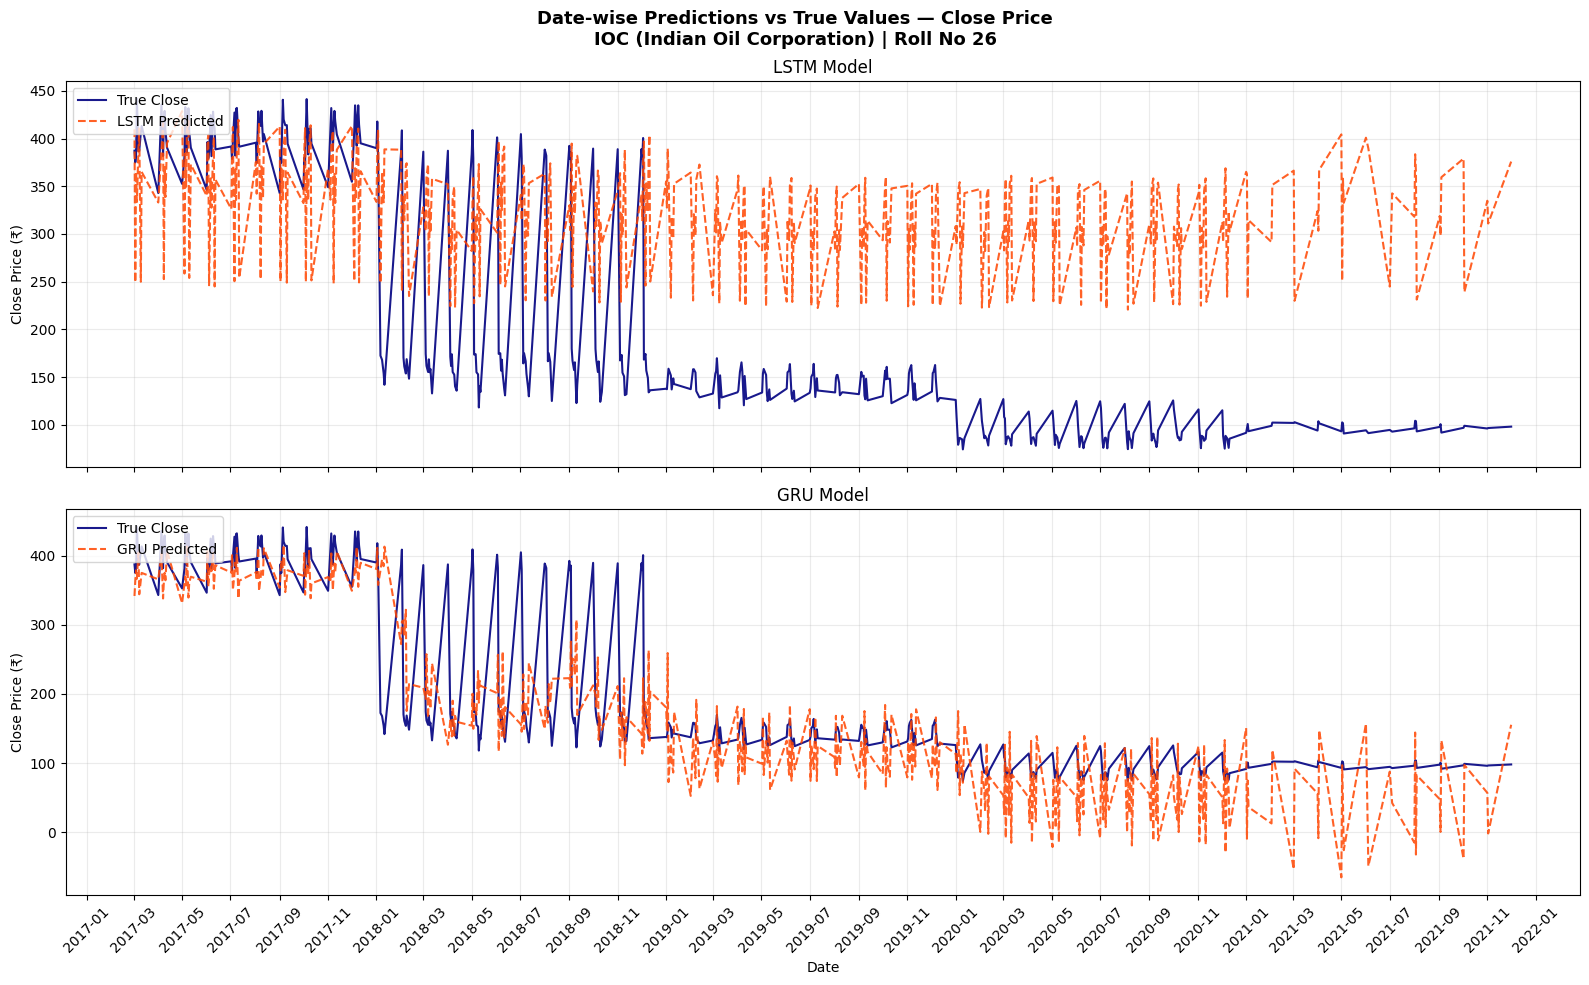

Saved: datewise_close_price.png


In [31]:
# ── Plot: Close price date-wise ────────────────────────────────────────────────
close_idx = available.index('Close')

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.suptitle('Date-wise Predictions vs True Values — Close Price\n'
             'IOC (Indian Oil Corporation) | Roll No 26', fontsize=13, fontweight='bold')

for ax, (model_name, pred_flat) in zip(axes, [
    ('LSTM', lstm_flat_inv),
    ('GRU',  gru_flat_inv)
]):
    ax.plot(date_arr, true_flat_inv[:, close_idx],
            label='True Close', color='navy', lw=1.5, alpha=0.9)
    ax.plot(date_arr, pred_flat[:, close_idx],
            label=f'{model_name} Predicted', color='orangered',
            lw=1.5, linestyle='--', alpha=0.85)
    ax.set_title(f'{model_name} Model', fontsize=12)
    ax.set_ylabel('Close Price (₹)')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.25)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.xticks(rotation=45)
plt.xlabel('Date')
plt.tight_layout()
plt.savefig('datewise_close_price.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: datewise_close_price.png")

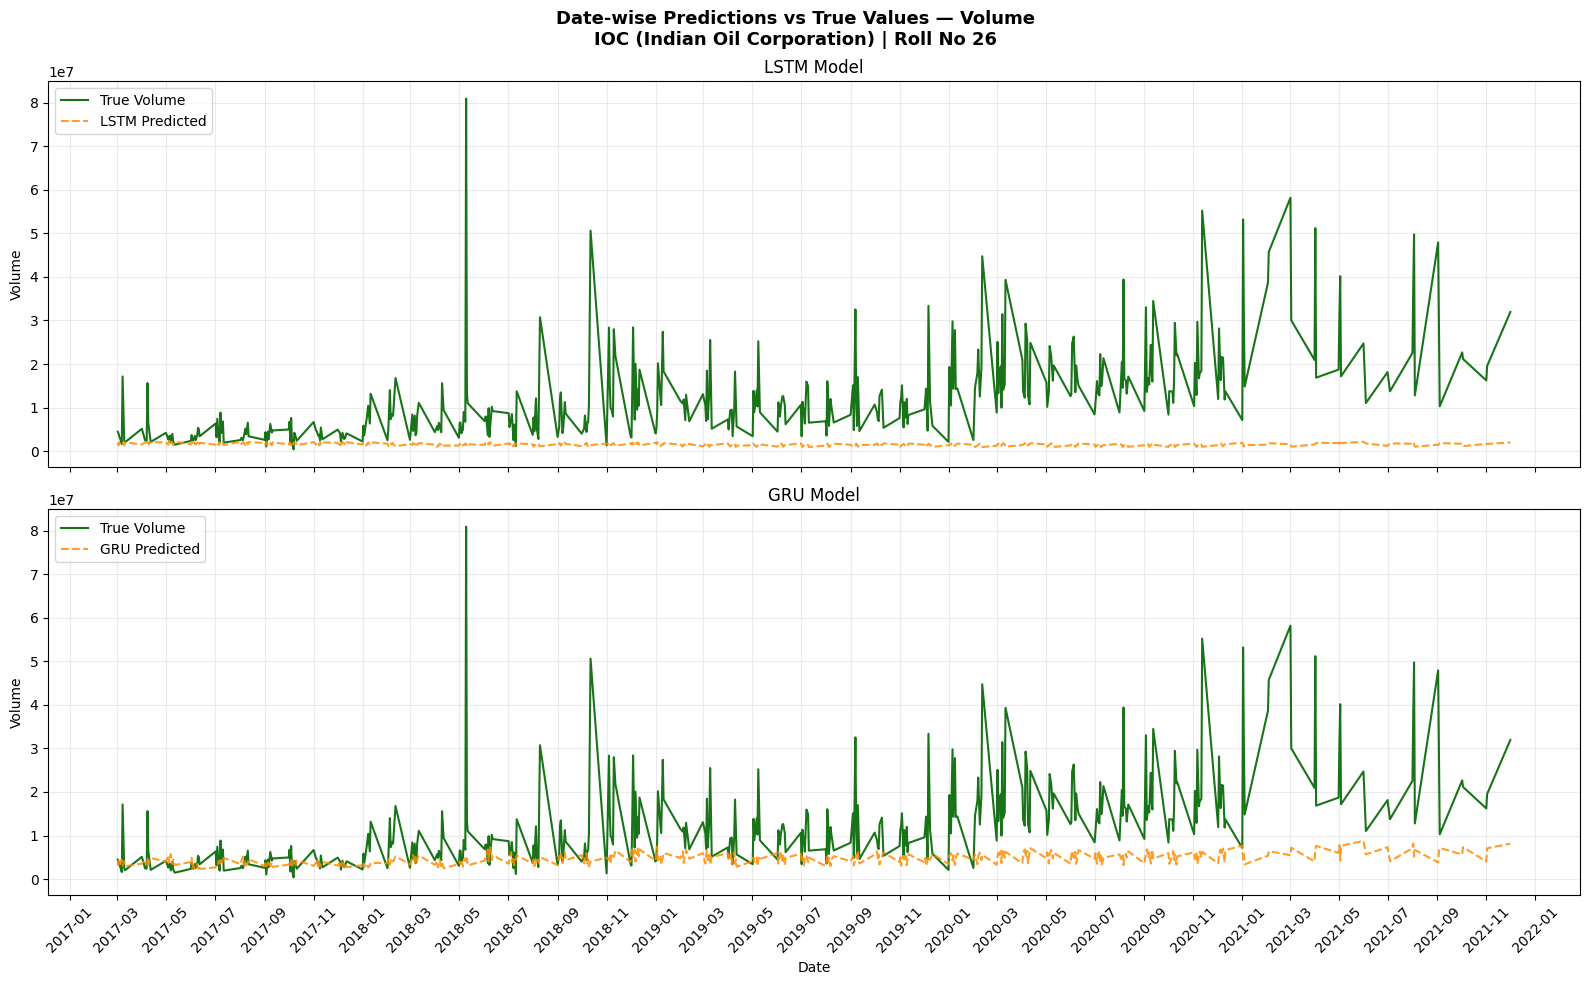

Saved: datewise_volume.png


In [32]:
# ── Plot: Volume date-wise ─────────────────────────────────────────────────────
vol_idx = available.index('Volume')

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.suptitle('Date-wise Predictions vs True Values — Volume\n'
             'IOC (Indian Oil Corporation) | Roll No 26', fontsize=13, fontweight='bold')

for ax, (model_name, pred_flat) in zip(axes, [
    ('LSTM', lstm_flat_inv),
    ('GRU',  gru_flat_inv)
]):
    ax.plot(date_arr, true_flat_inv[:, vol_idx],
            label='True Volume', color='darkgreen', lw=1.5, alpha=0.9)
    ax.plot(date_arr, pred_flat[:, vol_idx],
            label=f'{model_name} Predicted', color='darkorange',
            lw=1.5, linestyle='--', alpha=0.85)
    ax.set_title(f'{model_name} Model', fontsize=12)
    ax.set_ylabel('Volume')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.25)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.xticks(rotation=45)
plt.xlabel('Date')
plt.tight_layout()
plt.savefig('datewise_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: datewise_volume.png")

### 9.4 LSTM vs GRU — All Features in One Graph

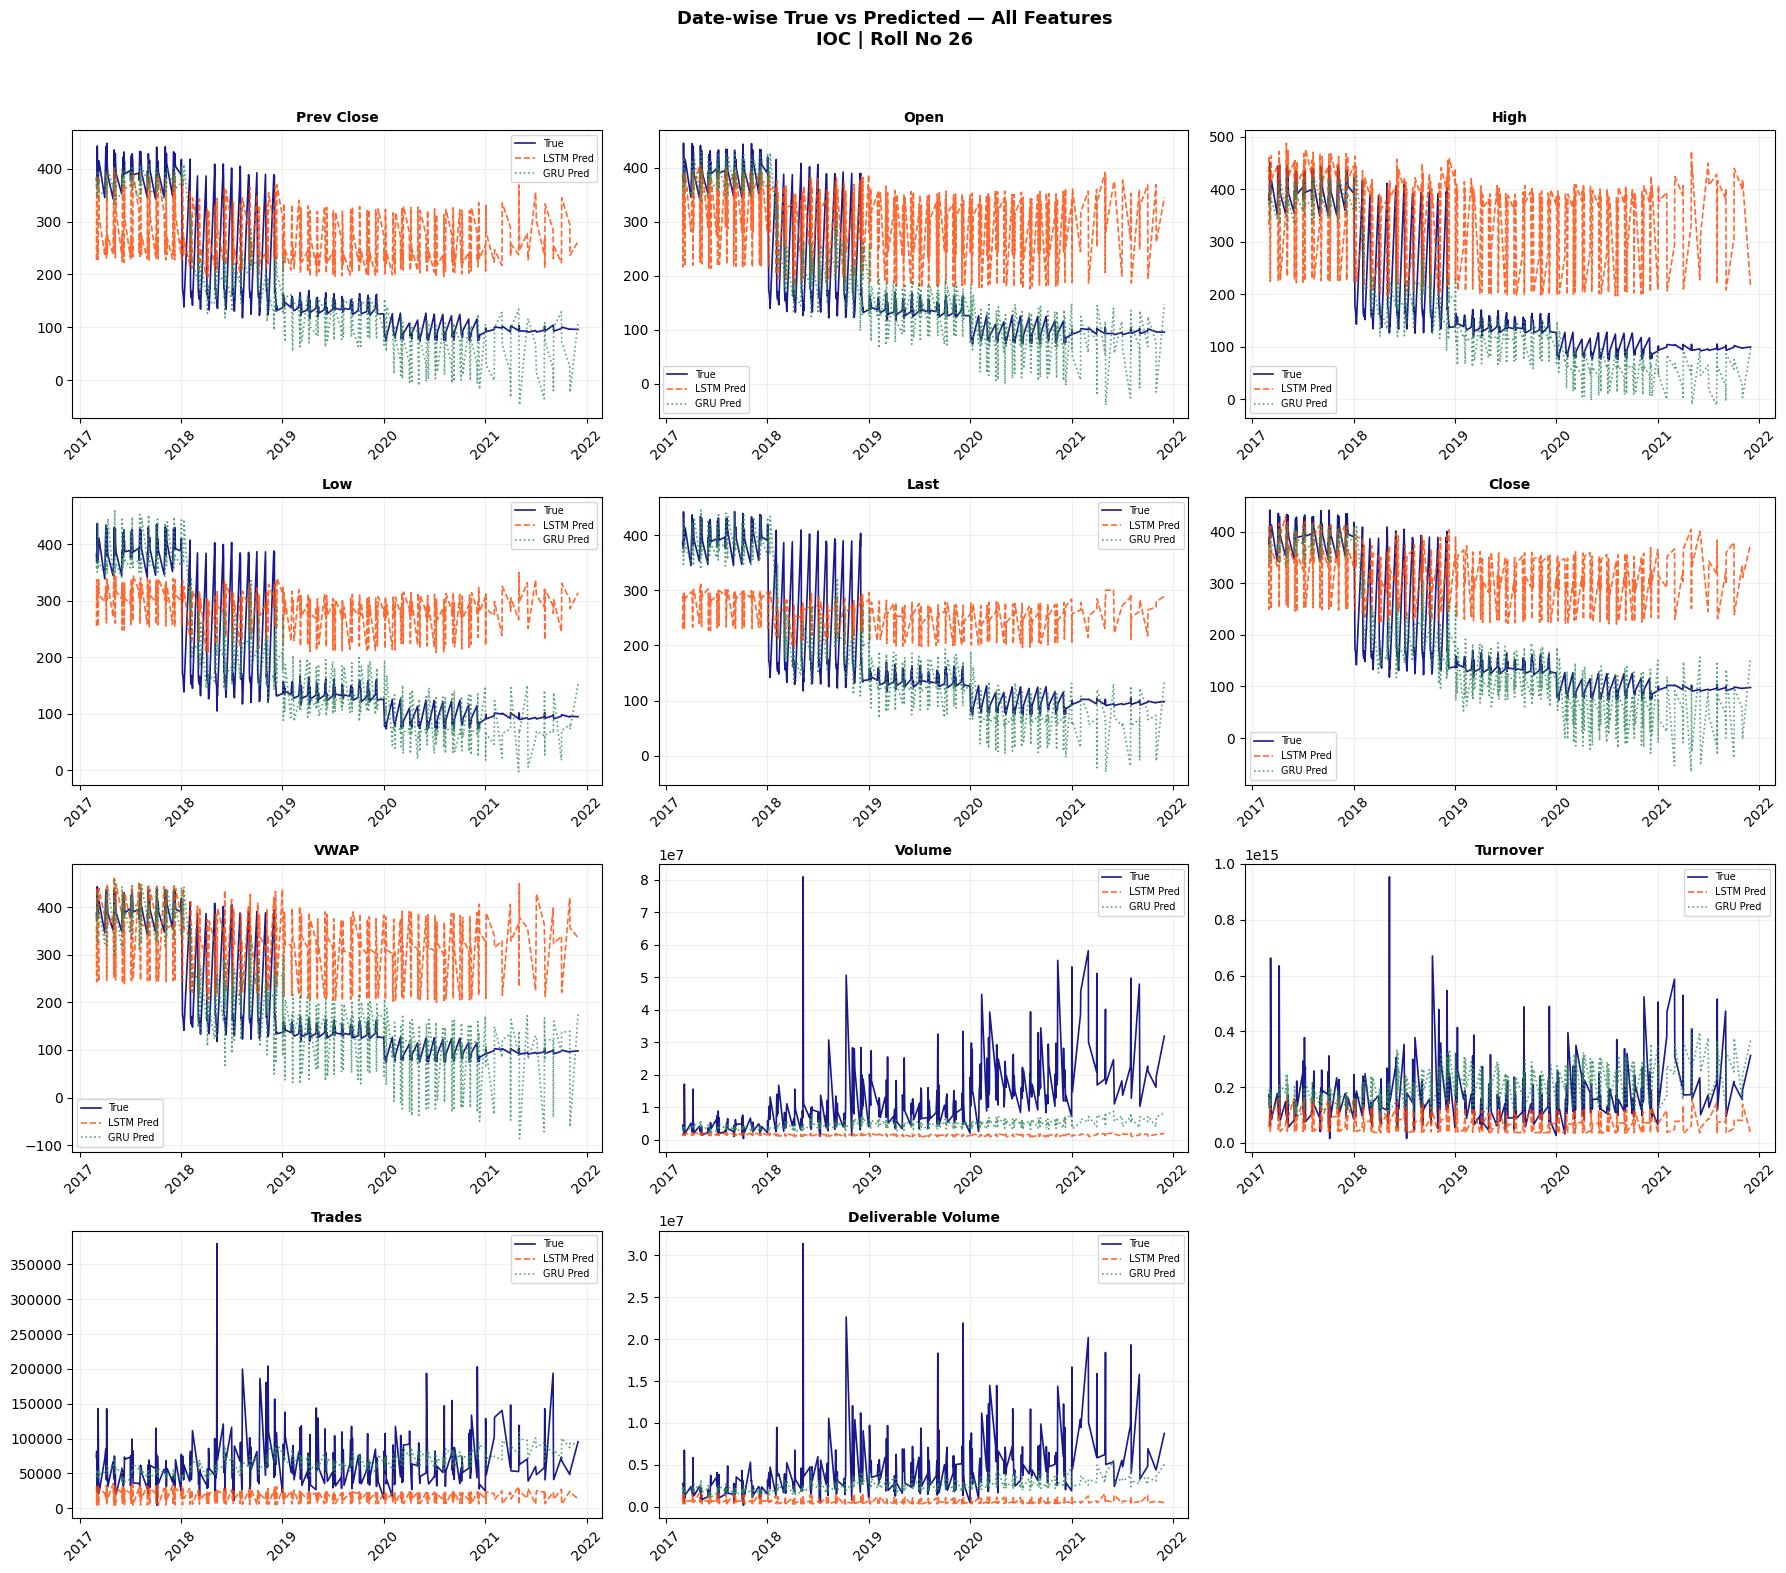

Saved: all_features_predictions.png


In [33]:
n_feat = len(available)
ncols  = 3
nrows  = (n_feat + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
fig.suptitle('Date-wise True vs Predicted — All Features\n'
             'IOC | Roll No 26', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(available):
    ax = axes[i]
    ax.plot(date_arr, true_flat_inv[:, i],
            label='True',      color='navy',     lw=1.2, alpha=0.9)
    ax.plot(date_arr, lstm_flat_inv[:, i],
            label='LSTM Pred', color='orangered', lw=1.2, linestyle='--', alpha=0.8)
    ax.plot(date_arr, gru_flat_inv[:, i],
            label='GRU Pred',  color='seagreen',  lw=1.2, linestyle=':',  alpha=0.8)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.2)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# Hide unused subplots
for j in range(n_feat, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('all_features_predictions.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: all_features_predictions.png")

## 10. Summary Table

In [34]:
print("╔══════════════════════════════════════════════════════════════╗")
print("║         FINAL RESULTS SUMMARY — IOC.csv  (Roll No 26)       ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  Input window   : {INPUT_LEN} days                                    ║")
print(f"║  Predict window : {PRED_LEN} days                                     ║")
print(f"║  Overlap        : {INPUT_LEN - STEP} days                                    ║")
print(f"║  Features       : {N_FEATURES} (all required)                          ║")
print("╠══════════════════════════════════════════════════════════════╣")

for mname, mdf in [('LSTM', lstm_metrics), ('GRU', gru_metrics)]:
    row = mdf.loc['** OVERALL **']
    print(f"║  {mname:<6}  MSE={row['MSE']:.4f}  RMSE={row['RMSE']:.4f}  MAE={row['MAE']:.4f}   ║")
print("╚══════════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════════╗
║         FINAL RESULTS SUMMARY — IOC.csv  (Roll No 26)       ║
╠══════════════════════════════════════════════════════════════╣
║  Input window   : 10 days                                    ║
║  Predict window : 5 days                                     ║
║  Overlap        : 5 days                                    ║
║  Features       : 11 (all required)                          ║
╠══════════════════════════════════════════════════════════════╣
║  LSTM    MSE=2112298737374665208710037504.0000  RMSE=45959751276248.9297  MAE=9789951180800.0000   ║
║  GRU     MSE=1451249628464507328554598400.0000  RMSE=38095270421201.9922  MAE=8487827406848.0000   ║
╚══════════════════════════════════════════════════════════════╝


## 11. Save Models

In [35]:
torch.save(lstm_model.state_dict(), 'lstm_ioc_model.pth')
torch.save(gru_model.state_dict(),  'gru_ioc_model.pth')
print("Models saved: lstm_ioc_model.pth  |  gru_ioc_model.pth")

Models saved: lstm_ioc_model.pth  |  gru_ioc_model.pth


---

## References

1. Kaggle NIFTY-50 Dataset: https://www.kaggle.com/datasets/rohanrao/nifty50-stock-market-data/data  
2. PyTorch LSTM Documentation: https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html  
3. PyTorch GRU Documentation: https://pytorch.org/docs/stable/generated/torch.nn.GRU.html  